<a href="https://colab.research.google.com/github/ColinaAndres/Heart-Disease-Prediction/blob/main/notebooks/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports y GoogleDrive Autenticacion

In [ ]:
import plotly.express as px
import plotly.figure_factory as ff
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
id = '1QHrv5jOfyW6znzSvY8U4eGgLsAWa_Ln0'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('heart_train.csv')

In [ ]:
id_test = '1ToTRlYQqwxhNn48T5JvIoEFxCxDmZRpR'
downloaded_test = drive.CreateFile({'id': id_test})
downloaded_test.GetContentFile('heart_test.csv')

# Carga del Dataset

In [ ]:
heart_data = pd.read_csv('heart_train.csv',encoding='latin1')

In [ ]:
test_data = pd.read_csv('heart_test.csv',encoding='latin1')

# Proceso de Machine Learning

## Division del set

In [ ]:
x = heart_data.drop('HeartDisease', axis=1)
y = heart_data['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_validation, y_train, y_validation = train_test_split(x, y, test_size=0.2, random_state=18)

## Preprocesamiento

Para el caso de RandomForest hacemos el encoding pero no hace falta normalizar.
Actualizacion: Se intento normalizar los valores de todas maneras pero el resultado es el mismo, se deja sin normalizar. Ademas imputar la media para el colesterol resulta contraproducente, nos quedamos con los valores 0.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoder.fit(x_train[cat_cols])

x_train_cat = encoder.transform(x_train[cat_cols])
x_validation_cat = encoder.transform(x_validation[cat_cols])
test_cat = encoder.transform(test_data[cat_cols])

Unimos los datos encoded con los numericos:

In [ ]:
encoded_col_names = encoder.get_feature_names_out(cat_cols)

x_train_cat_df = pd.DataFrame(x_train_cat, columns=encoded_col_names, index=x_train.index)
x_validation_cat_df = pd.DataFrame(x_validation_cat, columns=encoded_col_names, index=x_validation.index)
test_cat_df = pd.DataFrame(test_cat, columns=encoded_col_names, index=test_data.index)

x_train_final = pd.concat([x_train[num_cols], x_train_cat_df], axis=1)
x_validation_final = pd.concat([x_validation[num_cols], x_validation_cat_df], axis=1)
test_final = pd.concat([test_data[num_cols], test_cat_df], axis=1)

In [ ]:
x_train_final.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,FastingBS,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
542,41,120,157,182,0.0,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
694,55,140,229,110,0.5,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
194,48,140,238,118,0.0,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
131,57,140,265,145,1.0,0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
653,66,112,261,140,1.5,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
x_validation_final.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,FastingBS,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
627,45,180,295,180,0.0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
256,60,120,246,135,0.0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
192,54,120,246,110,0.0,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
380,50,150,243,128,2.6,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
643,62,158,170,138,0.0,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


## Hiperparametros

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
random_state_ = 4
rf = RandomForestClassifier(random_state=random_state_)

In [ ]:
parametros_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 30, 40, 50],
    'min_samples_split': [2, 5, 8, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt'],
    'bootstrap': [True],
}

In [ ]:
rs_rf = RandomizedSearchCV(estimator=rf, param_distributions=parametros_rf,
                           n_iter=5, cv=5, scoring='roc_auc', random_state=random_state_, n_jobs=-1)

In [ ]:
rs_rf.fit(x_train_final, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=4),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 30, 40, 50],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 8, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=4, scoring='roc_auc')

In [ ]:
rs_rf.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=30, min_samples_leaf=4,
                       min_samples_split=10, random_state=4)

In [ ]:
model = rs_rf.best_estimator_

In [ ]:
model.fit(x_train_final, y_train)

RandomForestClassifier(criterion='entropy', max_depth=30, min_samples_leaf=4,
                       min_samples_split=10, random_state=4)

## Evaluacion Del Modelo

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [ ]:
y_pred = model.predict(x_validation_final)
y_validation = y_validation.astype(int)

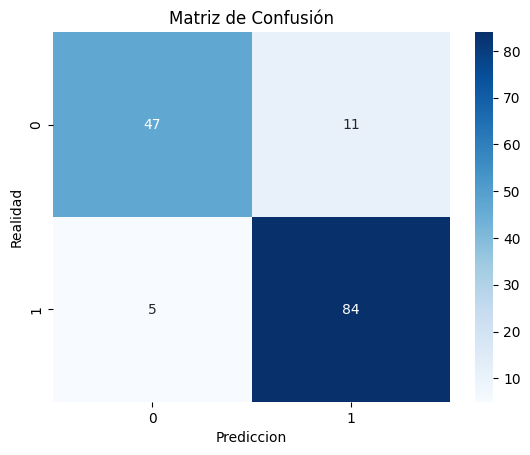

In [ ]:
cm = confusion_matrix(y_validation, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Prediccion')
plt.ylabel('Realidad')
plt.show()

Calculo de Accuracy:

In [ ]:
accuracy_score(y_validation, y_pred)

0.891156462585034

Calculo de recall:

In [ ]:
recall_score = cm[1][1] / sum(cm[1])
recall_score

np.float64(0.9438202247191011)

Calculo Roc_Auc:

In [ ]:
y_pred = y_pred.astype(str)
y_validation = y_validation.astype(str)
y_prob = model.predict_proba(x_validation_final)[:, 1]
roc_auc_score(y_validation, y_prob)

np.float64(0.9372336303758233)

## Features mas importantes

In [ ]:
import plotly.graph_objs as go

importances = model.feature_importances_

df_importances = pd.DataFrame({
    'Feature': x_train_final.columns,
    'Importance': importances
})

df_importances = df_importances.sort_values(by='Importance', ascending=True)

fig = go.Figure(go.Bar(
    x=df_importances['Importance'],
    y=df_importances['Feature'],
    orientation='h',
    marker=dict(
        color=df_importances['Importance'],
        colorscale='cividis',
        showscale=True
    ),
))

fig.update_layout(
    title='Importancia de Features - Random Forest',
    title_font=dict(size=24, family='Arial', color='black'),
    xaxis=dict(
        title='Importancia',
        titlefont=dict(size=18),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title='Features',
        titlefont=dict(size=18),
        tickfont=dict(size=14)
    ),
    margin=dict(l=200, r=50, t=70, b=50),
    showlegend=False
)

fig.show()

# Prediccion para la competencia

Este modelo no es el mejor, solo se revisa para la competencia como dato extra

In [ ]:
prediccion = model.predict(test_final)

In [ ]:
submission_rf = pd.DataFrame({'id': range(len(prediccion)), 'HeartDisease': prediccion})

In [ ]:
submission_rf.to_csv('submission_rf.csv', index=False)